# Introduction
In this notebook, we will conduct exploratory data analysis on our given dataset in order to find
patterns with the features available and resolution time. *Note: the dataset used contains all 
incidents **opened** in 2025, including those which went into the next year (for example a case 
opened on New Years Eve)*.

> In a seperate Tableau Public story, we dive into some characteristics of the dataset. The 
> [**NYC311 Resolution Time Analysis**](https://public.tableau.com/app/profile/luis.jaco8183/viz/nyc311_17861374235790/nyc311)
> viz gives an interactive view of datapoints and patterns which can be seen with resolution time.
> Some of the observations made in the viz will be repeated here for brevity.


# Setup

In [1]:
# setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use('seaborn-v0_8')

In [2]:
# grab data
df = pd.read_csv('../data/nyc311_2025.csv', index_col='id')

In [3]:
# # set time columns
df = df.astype({
    'created' : 'datetime64[ns]',
    'closed' : 'datetime64[ns]',
    'zipcode': 'category'
})

In [4]:
df.head(25)

,created,closed,agency_name,problem,detail,borough,lat,long,method,zipcode,resolution_time
id,,,,,,,,,,,
67351762,2025-12-31 23:59:28,2026-01-01 00:40:32,New York City Police Department,Noise - Residential,Loud Music/Party,MANHATTAN,40.792141,-73.950097,MOBILE,10029,0.684
67344624,2025-12-31 23:59:23,2026-01-01 01:03:42,New York City Police Department,Noise - Residential,Loud Music/Party,MANHATTAN,40.825137,-73.949447,ONLINE,10031,1.072
67346873,2025-12-31 23:59:21,2026-01-01 00:58:13,New York City Police Department,Blocked Driveway,Partial Access,BROOKLYN,40.619995,-73.921167,PHONE,11234,0.981
67353004,2025-12-31 23:59:20,2026-01-01 00:57:31,New York City Police Department,Noise - Residential,Loud Music/Party,BROOKLYN,40.591542,-73.955979,ONLINE,11235,0.970
67350526,2025-12-31 23:59:12,2026-01-01 00:41:16,New York City Police Department,Noise - Commercial,Loud Music/Party,MANHATTAN,40.822593,-73.949525,MOBILE,10031,0.701
67349434,2025-12-31 23:59:08,2026-01-01 00:44:09,New York City Police Department,Noise - Residential,Loud Music/Party,BROOKLYN,40.629373,-73.928005,ONLINE,11234,0.750
67351447,2025-12-31 23:58:39,2026-01-01 01:17:13,New York City Police Department,Illegal Parking,Blocked Hydrant,BROOKLYN,40.600331,-73.999910,ONLINE,11214,1.309
67346934,2025-12-31 23:58:33,2026-01-01 00:13:13,New York City Police Department,Illegal Fireworks,NaN,QUEENS,40.755999,-73.863399,ONLINE,11368,0.244
67348119,2025-12-31 23:58:32,2026-01-01 01:39:38,New York City Police Department,Noise - Commercial,Loud Music/Party,BROOKLYN,40.615034,-73.994334,MOBILE,11204,1.685


In [5]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 3475290 entries, 67351762 to 63577994
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   created          3475290 non-null  datetime64[ns]
 1   closed           3475290 non-null  datetime64[ns]
 2   agency_name      3475290 non-null  str           
 3   problem          3475290 non-null  str           
 4   detail           3404944 non-null  str           
 5   borough          3475290 non-null  str           
 6   lat              3475290 non-null  float64       
 7   long             3475290 non-null  float64       
 8   method           3475290 non-null  str           
 9   zipcode          3475290 non-null  category      
 10  resolution_time  3475290 non-null  float64       
dtypes: category(1), datetime64[ns](2), float64(3), str(5)
memory usage: 298.3 MB


# Feature Engineering
There are a couple of features which can be extracted to analyze and use in our analysis. Firstly, the
goal of this project is to predict the resolution time given an incident.

We can expand our dataset by adding the following columns:

| name  | from      | description  |
|-------|-----------|--------------|
| c_day   | `created` | day created [1-31]   |
| c_hour  | `created` | hour created [0-23]  |
| c_month | `created` | month created [1-12] |

In [6]:
# date features
df['c_day'] = df['created'].dt.day
df['c_hour'] = df['created'].dt.hour
df['c_month'] = df['created'].dt.month

In [7]:
df.describe(include='all')

,created,closed,agency_name,problem,detail,borough,lat,long,method,zipcode,resolution_time,c_day,c_hour,c_month
count,3475290,3475290,3475290,3475290,3404944,3475290,3.475290e+06,3.475290e+06,3475290,3475290.0,3.475290e+06,3.475290e+06,3.475290e+06,3.475290e+06
unique,NaN,NaN,15,175,866,6,NaN,NaN,5,245.0,NaN,NaN,NaN,NaN
top,NaN,NaN,New York City Police Department,Illegal Parking,Loud Music/Party,BROOKLYN,NaN,NaN,ONLINE,10466.0,NaN,NaN,NaN,NaN
freq,NaN,NaN,1702330,574066,492674,1029319,NaN,NaN,1511814,153673.0,NaN,NaN,NaN,NaN
mean,2025-07-05 00:21:58.433245952,2025-07-14 17:14:57.506631424,NaN,NaN,NaN,NaN,4.074094e+01,-7.391982e+01,NaN,NaN,2.328831e+02,1.552551e+01,1.311481e+01,6.612282e+00
min,2025-01-01 00:00:12,2025-01-01 00:05:19,NaN,NaN,NaN,NaN,4.049891e+01,-7.425495e+01,NaN,NaN,1.000000e-03,1.000000e+00,0.000000e+00,1.000000e+00
25%,2025-04-03 07:59:06.500000,2025-04-11 06:58:27.249999872,NaN,NaN,NaN,NaN,4.067535e+01,-7.396304e+01,NaN,NaN,1.126000e+00,8.000000e+00,9.000000e+00,4.000000e+00
50%,2025-07-07 16:33:50.500000,2025-07-17 14:15:57,NaN,NaN,NaN,NaN,4.073325e+01,-7.392233e+01,NaN,NaN,7.092000e+00,1.500000e+01,1.300000e+01,7.000000e+00
75%,2025-10-07 13:05:53,2025-10-15 17:26:28.500000,NaN,NaN,NaN,NaN,4.082318e+01,-7.386844e+01,NaN,NaN,6.933300e+01,2.300000e+01,1.800000e+01,1.000000e+01
max,2025-12-31 23:59:28,2026-07-25 21:02:54,NaN,NaN,NaN,NaN,4.091287e+01,-7.370037e+01,NaN,NaN,1.360887e+04,3.100000e+01,2.300000e+01,1.200000e+01


# Singling Out an Agency
As seen in the notebook (we will give an example here), problems do not intersect within the **NYC311**
dataset. As such, it would be unwise to use one all-agency model. The optimal choice is to instead
use per-agency models which only interacts with the relevant data specific to the particular agency.

Below, we will analyze some per-agency statistics using SQL-like `pandas` commands to analyze the 
differences within each agency.

In [8]:
# counts of incidents in 2025 by agency
df.groupby('agency_name')['created'].count().sort_values(ascending=False)

agency_name
New York City Police Department                       1702330
Department of Housing Preservation and Development     770409
Department of Sanitation                               315910
Department of Environmental Protection                 175160
Department of Transportation                           173641
Department of Parks and Recreation                      93378
Department of Buildings                                 89659
Department of Health and Mental Hygiene                 54212
Department of Homeless Services                         40611
Taxi and Limousine Commission                           28038
Department of Consumer and Worker Protection            18052
Economic Development Corporation                        10881
Department of Education                                  1697
Office of the Sheriff                                    1108
Office of Technology and Innovation                       204
Name: created, dtype: int64

In [9]:
# distinct problem counts, you can observe this to find that there is a lack of problem overlap, if any
df.groupby('agency_name')['problem'].value_counts()

agency_name                    problem                                
Department of Buildings        General Construction/Plumbing              29853
                               Elevator                                   20812
                               Building/Use                               19268
                               Boilers                                     3635
                               Special Projects Inspection Team (SPIT)     3566
                                                                          ...  
Taxi and Limousine Commission  For Hire Vehicle Report                       29
                               Found Property                                 2
                               Taxi Licensee Complaint                        2
                               Green Taxi Report                              2
                               FHV Licensee Complaint                         2
Name: count, Length: 179, dtype: int64

In [10]:
# describe resolution time
df.groupby('agency_name')['resolution_time'].describe().T

agency_name,Department of Buildings,Department of Consumer and Worker Protection,Department of Education,Department of Environmental Protection,Department of Health and Mental Hygiene,Department of Homeless Services,Department of Housing Preservation and Development,Department of Parks and Recreation,Department of Sanitation,Department of Transportation,Economic Development Corporation,New York City Police Department,Office of Technology and Innovation,Office of the Sheriff,Taxi and Limousine Commission
count,89659.000000,18052.000000,1697.000000,175160.000000,54212.000000,40611.000000,770409.000000,93378.000000,315910.000000,173641.000000,10881.000000,1.702330e+06,204.000000,1108.000000,28038.000000
mean,1461.041797,369.001679,2893.203847,98.864531,728.282093,111.774063,367.803464,1119.146283,87.406070,253.429192,7278.278411,2.970705e+00,413.051632,973.730718,2159.055369
std,2022.823055,547.865861,3316.740438,376.203922,831.502412,343.634161,764.883207,2012.351455,197.704845,745.278316,1940.648225,9.095660e+00,445.634481,192.938030,2104.716129
min,0.001000,2.532000,0.016000,0.017000,0.001000,0.013000,0.001000,0.003000,0.002000,0.006000,218.400000,1.000000e-03,1.033000,1.484000,0.006000
25%,59.333000,26.697500,113.144000,5.233000,23.678500,2.694000,38.706000,27.318750,15.287000,15.350000,6597.928000,5.610000e-01,209.590250,937.599500,406.599000
50%,467.997000,97.824500,1344.571000,24.667000,313.733500,6.977000,79.302000,196.968500,32.824500,62.317000,7845.186000,1.269000e+00,355.419000,1007.921000,1488.174500
75%,2099.702000,733.129500,5246.288000,88.800000,1440.220000,21.437500,319.686000,1153.522000,77.543750,213.689000,8473.932000,3.090000e+00,498.727000,1072.716750,3615.506750
max,13413.928000,8242.700000,11927.436000,13465.167000,10370.045000,6909.149000,12843.707000,13464.056000,9777.388000,13608.867000,10444.920000,2.262734e+03,4843.530000,1338.601000,12341.948000


In [11]:
# describe categorical variables
df.groupby('agency_name')[['problem', 'borough', 'method']].describe(include='str').T

agency_name           Department of Buildings  \
problem count                           89659   
        unique                             20   
        top     General Construction/Plumbing   
        freq                            29853   
borough count                           89659   
        unique                              6   
        top                          BROOKLYN   
        freq                            28008   
method  count                           89659   
        unique                              1   
        top                           UNKNOWN   
        freq                            89659   

agency_name    Department of Consumer and Worker Protection  \
problem count                                         18052   
        unique                                            1   
        top                              Consumer Complaint   
        freq                                          18052   
borough count                                         18052   
        unique                                            6   
        top                                        BROOKLYN   
        freq                                           5343   
method  count                                         18052   
        unique                                            2   
        top                                           PHONE   
        freq                                           9159   

agency_name    Department of Education Department of Environmental Protection  \
problem count                     1697                                 175160   
        unique                       1                                     11   
        top         School Maintenance                           Water System   
        freq                      1697                                  58331   
borough count                     1697                                 175160   
        unique                       5                                      6   
        top                     QUEENS                               BROOKLYN   
        freq                       506                                  50365   
method  count                     1697                                 175160   
        unique                       2                                      4   
        top                     ONLINE                                 ONLINE   
        freq                      1153                                  99164   

agency_name    Department of Health and Mental Hygiene  \
problem count                                    54212   
        unique                                      35   
        top                         Food Establishment   
        freq                                     12775   
borough count                                    54212   
        unique                                       6   
        top                                  MANHATTAN   
        freq                                     17719   
method  count                                    54212   
        unique                                       5   
        top                                     ONLINE   
        freq                                     24808   

agency_name    Department of Homeless Services  \
problem count                            40611   
        unique                               2   
        top         Homeless Person Assistance   
        freq                             26781   
borough count                            40611   
        unique                               6   
        top                          MANHATTAN   
        freq                             28035   
method  count                            40611   
        unique                               4   
        top                             MOBILE   
        freq                             21033   

agency_name    Department of Housing Preservation and Development  \
problem count

# Separating Analysis by Agency
Problems show little to no intersection, and distributions of `resolution_time` and other columns
vary depending on the agency. As such, we will continue our *exploratory data analysis* using a 
subset of the agencies, the New York City Police Department (**NYPD**), Department of 
Transportation (**DOT**), and the Taxi and Limousine Commission (**TLC**). These agencies are chosen
because they represent our data at difference scales, the NYPD being the most used agency, TLC being
the least used agency, and DOT being approximately in the middle.

The following analysis' will be carried out on all three. Overall, the observations should be 
different among each agency, yet we can say that the correlation between features and 
`resolution_time` remain consistent among the agencies.

In [12]:
# create datasets

nypd = df[df.agency_name == 'New York City Police Department']
dot = df[df.agency_name == 'Department of Transportation']
tlc = df[df.agency_name == 'Taxi and Limousine Commission']

agencies = df[df.agency_name.isin(['New York City Police Department', 'Department of Transportation', 'Taxi and Limousine Commission'])]
len(nypd), len(dot), len(tlc), len(agencies)

(1702330, 173641, 28038, 1904009)

# Intial distribution

In [13]:
def plot_time_resolution_dist(agency, agency_name, c):
    _, axes = plt.subplots(nrows=1, ncols=4, figsize=(28, 4))

    # boxplot with outliers
    sns.boxplot(data=agency, x='resolution_time', showfliers=True, color=c, ax=axes[0])
    axes[0].set(title=f'{agency_name} Resolution Time Boxplot', xlabel='Resolution Time (hours)')

    # boxplot without outliers
    sns.boxplot(data=agency, x='resolution_time', showfliers=False, color=c, ax=axes[1])
    axes[1].set(title=f'{agency_name} Resolution Time Boxplot (outliers removed)', xlabel='Resolution Time (hours)')

    # distribution plot (scaled to boxplot min-max)
    sns.kdeplot(
        data=agency, x='resolution_time', fill=True, color=c,
        ax=axes[2]
    )
    axes[2].set(title=f'{agency_name} Resolution Time Distribution', xlabel='Resolution Time (hours)')

    # distribution plot (scaled to boxplot min-max)
    sns.kdeplot(
        data=agency, x='resolution_time', fill=True, color=c, 
        clip=[0, agency.resolution_time.quantile(0.75) + 1.5*(agency.resolution_time.quantile(0.75) - agency.resolution_time.quantile(0.25))], # 0 (minimum) to boxplot maximum (q3 + 1.5*iqr)
        ax=axes[3]
    )
    axes[3].set(title=f'{agency_name} Resolution Time Distribution (scaled, outliers removed)', xlabel='Resolution Time (hours)')

    plt.show()

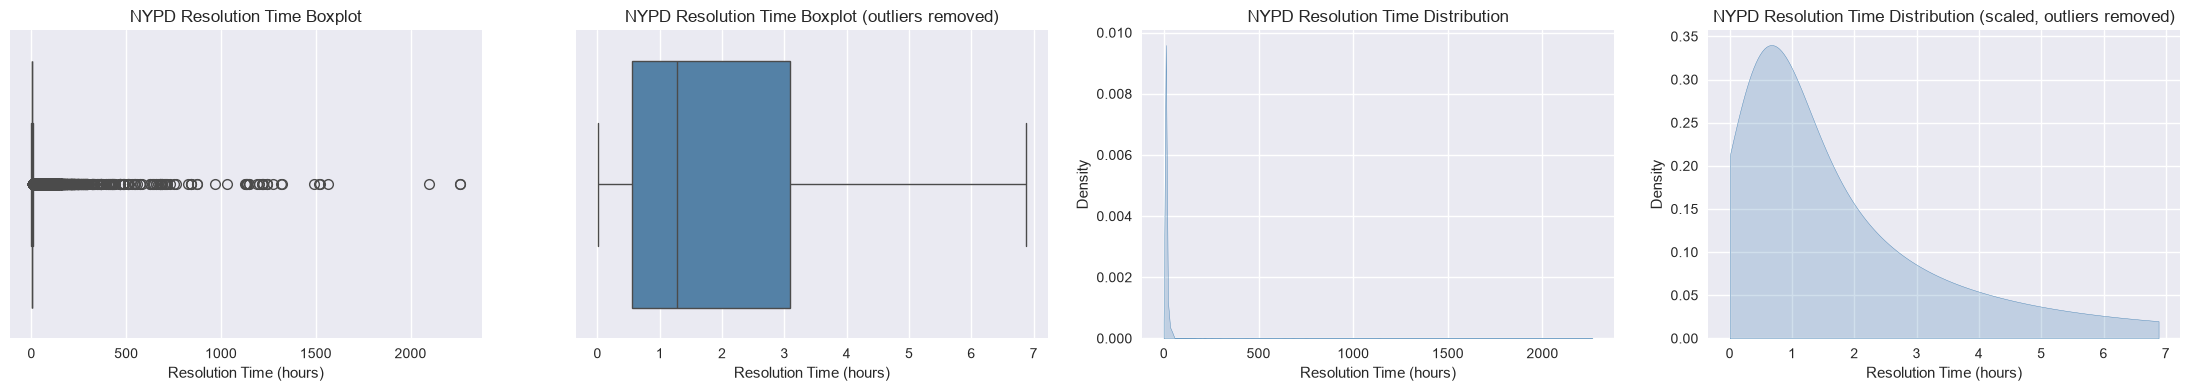

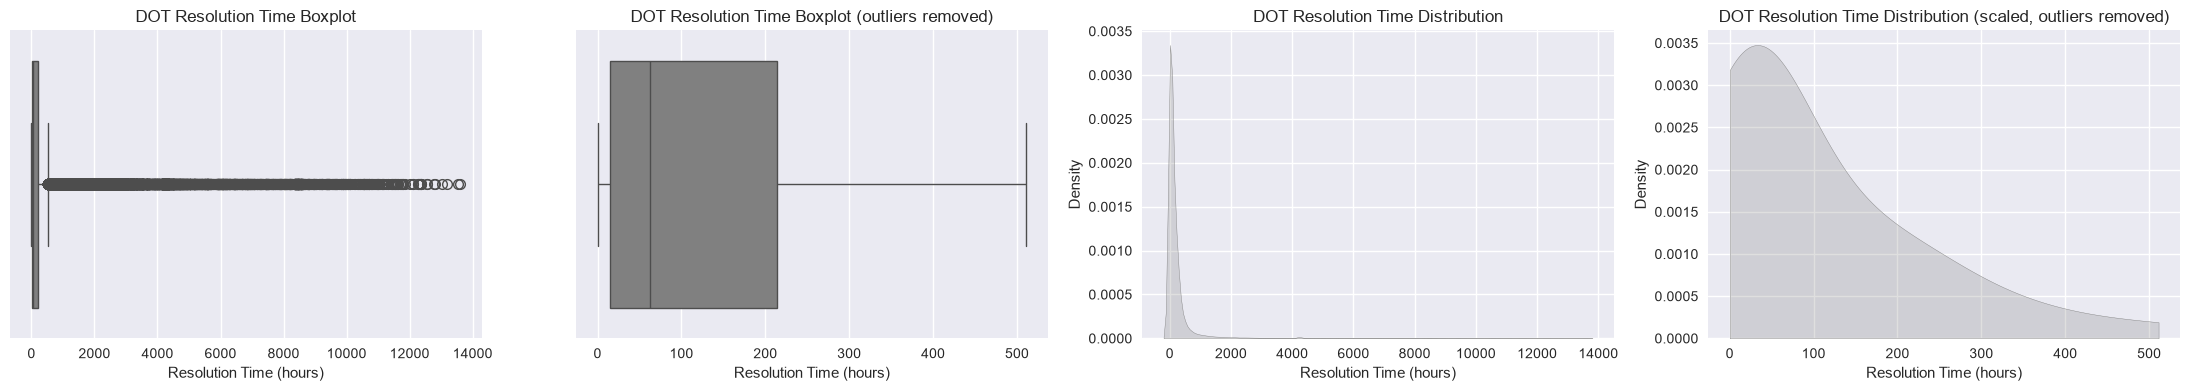

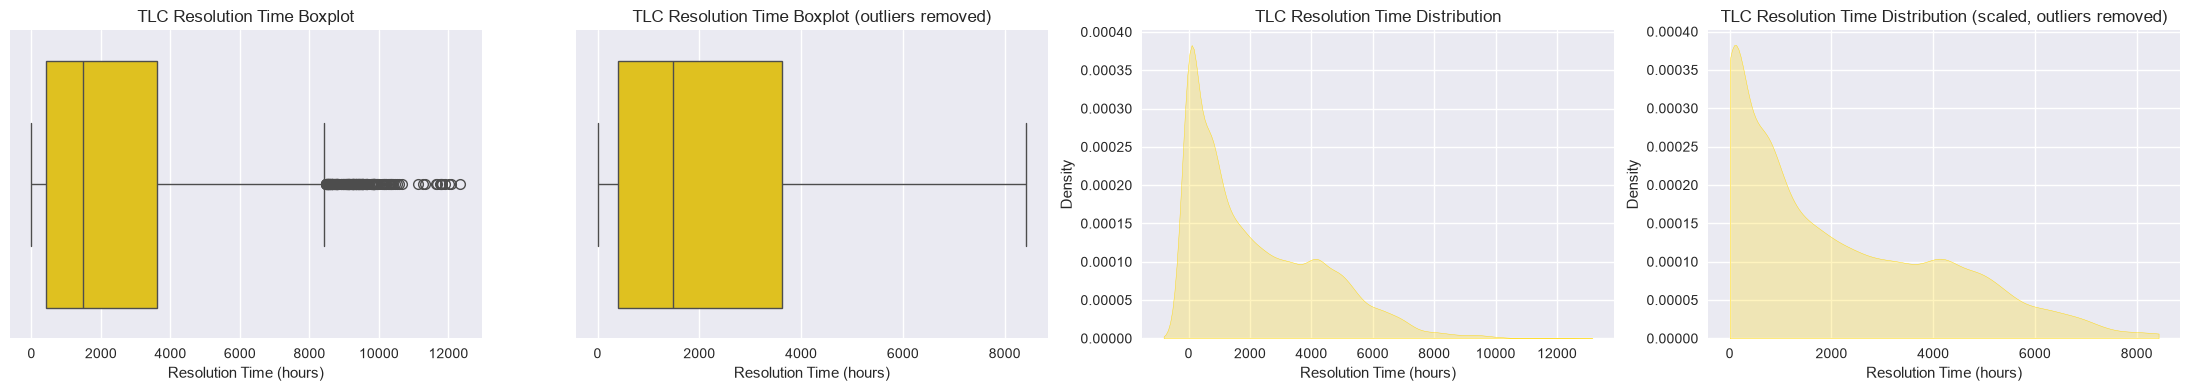

In [14]:
plot_time_resolution_dist(nypd, 'NYPD', 'steelblue')
plot_time_resolution_dist(dot, 'DOT', 'gray')
plot_time_resolution_dist(tlc, 'TLC', 'gold')

## Observations
- All distributions are skewed, with varying interquartile ranges. It can be observed that each
agency has its own range of resolution times.
- **NYPD**: The distribution is fairly low, however features many outliers. 75% of data is within 
the $[0, 7]$ hour range. There is a narrow distribution of resolution times.
- **DOT**: The distribution is higher than the **NYPD**, and features much more outliers than the 
other two agencies. The **DOT** has the outlier with the highest `time_resolution`.
- **TLC**: The distribution is much higher than the **NYPD**, and features less outliers than both
the **NYPD** and the **DOT**. Overall there is a much wider spread of resolution times.

# Per-Problem Distribution
Each agency has its own set of problems, which each may have their own `resolution_time` statistics.
Lets look into these characteristics using a `kdeplot`. This plot will show the density of each 
problem (of the entire agency) and the distribution of the `resolution_time`.

In [15]:
palette_25 = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
    "#42d4f4", "#f032e6", "#469990", "#9a6324", "#800000",
    "#808000", "#000075", "#e6a817", "#3a5311", "#a9273a",
    "#008080", "#7c3f00", "#5c2751", "#2f4f4f", "#000000",
    "#c71585", "#556b2f", "#8b0000", "#483d8b", "#b8860b"
]

def plot_per_problem(agency, agency_name):
    _, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))

    # distribution plot (scaled to boxplot min-max)
    lg = sns.kdeplot(
        data=agency, x='resolution_time', hue='problem', palette=palette_25,
        clip=[0, agency.resolution_time.quantile(0.75) + 1.5*(agency.resolution_time.quantile(0.75) - agency.resolution_time.quantile(0.25))], # 0 (minimum) to boxplot maximum (q3 + 1.5*iqr)
        ax=axes, warn_singular=False, legend=True
    )
    axes.set(title=f'{agency_name} Per-Problem Resolution Time Distribution (scaled)', xlabel='Resolution Time (hours)')

    sns.move_legend(lg, 'upper left', bbox_to_anchor=(1, 1))
    plt.show()

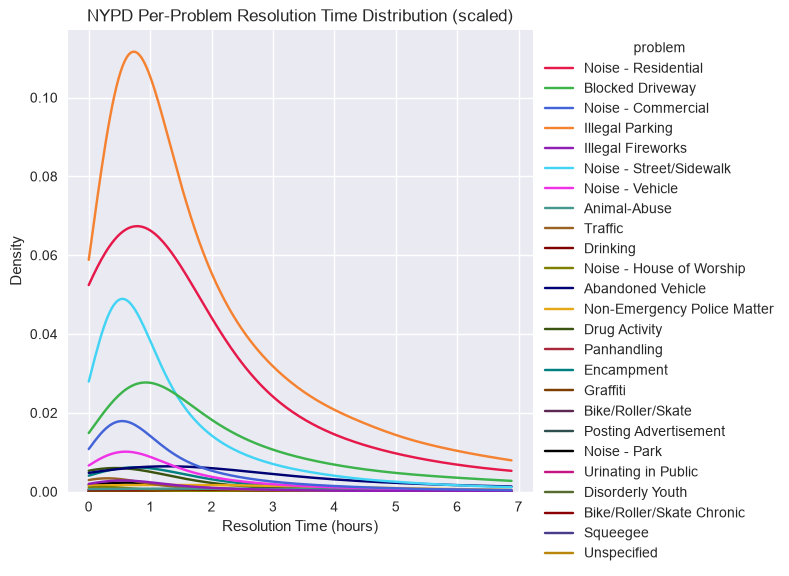

/var/folders/x4/j70qy1ns0gdg8282hfmvlbm80000gn/T/ipykernel_78706/1900286633.py:13: UserWarning: The palette list has more values (25) than needed (21), which may not be intended.
  lg = sns.kdeplot(


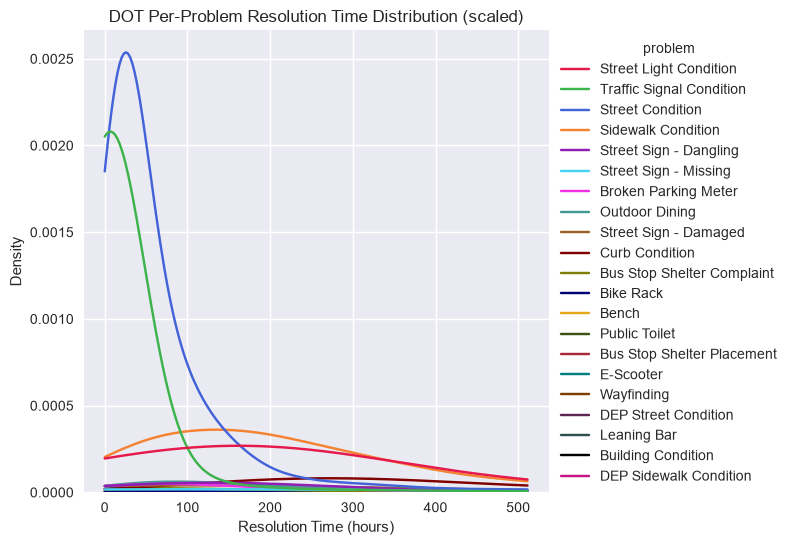

/var/folders/x4/j70qy1ns0gdg8282hfmvlbm80000gn/T/ipykernel_78706/1900286633.py:13: UserWarning: The palette list has more values (25) than needed (11), which may not be intended.
  lg = sns.kdeplot(


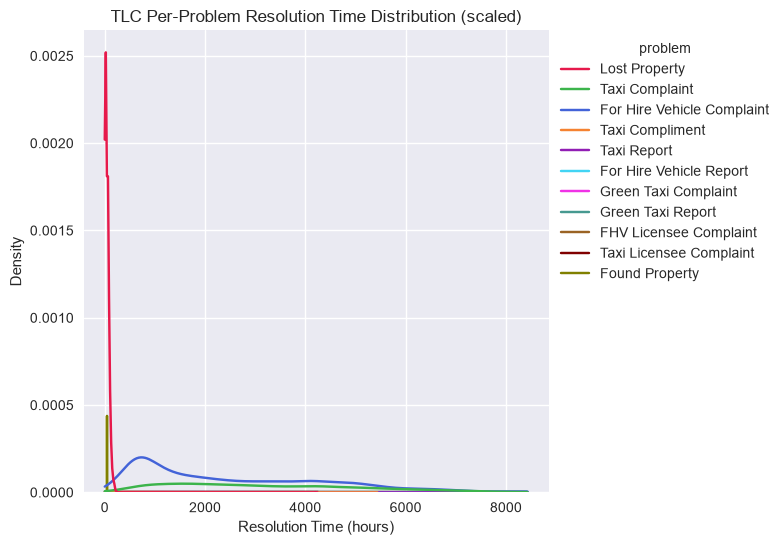

In [16]:
plot_per_problem(nypd, 'NYPD')
plot_per_problem(dot, 'DOT')
plot_per_problem(tlc, 'TLC')

## Observations
These plots show us both per-problem differences in frequency (density) as well as distribution.
- **NYPD**: Has *Illegal Parking* as the most common problem, with a narrow distrbution. The problem
with the widest distribution is *Blocked Driveway*.
- **DOT**: Both *Street Condition* and *Traffic Signal Condition* are the most frequent problems,
both featuring a much narrower distribution compared to the rest of the **DOT**'s problems.
- **TLC**: *Lost Property* is the most frequent problem, with a much narrower distribution, on a scale
much smaller compared to the rest of the problems which the **TLC** responds to, besides *Found Property*.

# Observations on Most Frequent Problems
We will now have a closer look on features and they relate to `resolution_time` on a per-problem basis.
It can also be said that we can make a model on each individual problem, as they are all separate 
entities which do not overlap. But to keep this project managable, we will have a model for each 
department.

As a baseline, we use the most common problem from each of the previously used agencies.

## Find Most Frequent Problem
Simple sanity check for concrete validation on the most common problems per agency.

In [17]:
# extract most frequent problems.
nypd.problem.value_counts()

problem
Illegal Parking                574066
Noise - Residential            462620
Blocked Driveway               172485
Noise - Street/Sidewalk        171879
Abandoned Vehicle               67233
Noise - Commercial              63813
Noise - Vehicle                 42780
Encampment                      30305
Drug Activity                   27953
Non-Emergency Police Matter     24593
Traffic                         11526
Illegal Fireworks               11252
Animal-Abuse                    10488
Noise - Park                    10035
Panhandling                      8983
Drinking                         4852
Noise - House of Worship         3061
Bike/Roller/Skate Chronic        1619
Urinating in Public              1405
Graffiti                          901
Disorderly Youth                  206
Posting Advertisement             139
Bike/Roller/Skate                 130
Squeegee                            5
Unspecified                         1
Name: count, dtype: int64

In [18]:
dot.problem.value_counts()

problem
Street Condition              48111
Traffic Signal Condition      40847
Street Light Condition        29263
Sidewalk Condition            25660
Curb Condition                 8066
Street Sign - Damaged          5191
Outdoor Dining                 3940
Street Sign - Dangling         3748
Street Sign - Missing          3290
Broken Parking Meter           2753
Bus Stop Shelter Complaint     1196
Bike Rack                       620
E-Scooter                       498
Bus Stop Shelter Placement      260
Bench                           118
Public Toilet                    42
Wayfinding                       19
DEP Street Condition             10
Building Condition                5
Leaning Bar                       3
DEP Sidewalk Condition            1
Name: count, dtype: int64

In [19]:
tlc.problem.value_counts()

problem
For Hire Vehicle Complaint    14691
Taxi Complaint                 6569
Lost Property                  6346
Green Taxi Complaint            266
Taxi Compliment                  88
Taxi Report                      41
For Hire Vehicle Report          29
Green Taxi Report                 2
FHV Licensee Complaint            2
Taxi Licensee Complaint           2
Found Property                    2
Name: count, dtype: int64

In [20]:
# create dataframes for each 
nypd_p = nypd[nypd.problem == 'Illegal Parking']
dot_p = dot[dot.problem == 'Street Condition']
tlc_p = tlc[tlc.problem == 'For Hire Vehicle Complaint']

print(nypd_p.problem.value_counts(), dot_p.problem.value_counts(), tlc_p.problem.value_counts(), sep='\n\n')

problem
Illegal Parking    574066
Name: count, dtype: int64

problem
Street Condition    48111
Name: count, dtype: int64

problem
For Hire Vehicle Complaint    14691
Name: count, dtype: int64


## Per-problem EDA

### Time Analysis
In the following cells we will look at time on varying levels of detail to examine how it affects 
`resolution_time`

In [21]:
def lineplots(title, col):
    """Will give a series of lineplots for each of the agencies most frequent problem and a specified column"""
    _, axes = plt.subplots(nrows=1, ncols=3, figsize=(26, 6))

    # nypd
    sns.lineplot(data=nypd_p, x=col, y='resolution_time', estimator='mean', ax=axes[0], color='steelblue')
    axes[0].set(title='NYPD \'Illegal Parking\' Average Resolution Time by ' + title, ylabel='Average Resolution Time (hours)', xlabel=title)

    # dot
    sns.lineplot(data=dot_p, x=col, y='resolution_time', estimator='mean', ax=axes[1], color='gray')
    axes[1].set(title='DOT \'Street Condition\' Average Resolution Time by ' + title, ylabel='Average Resolution Time (hours)', xlabel=title)

    # tlc
    sns.lineplot(data=tlc_p, x=col, y='resolution_time', estimator='mean', ax=axes[2], color='gold')
    axes[2].set(title='TLC \'For Hire Vehicle Complaint\' Average Resolution Time by ' + title, ylabel='Average Resolution Time (hours)', xlabel=title)

    plt.show()

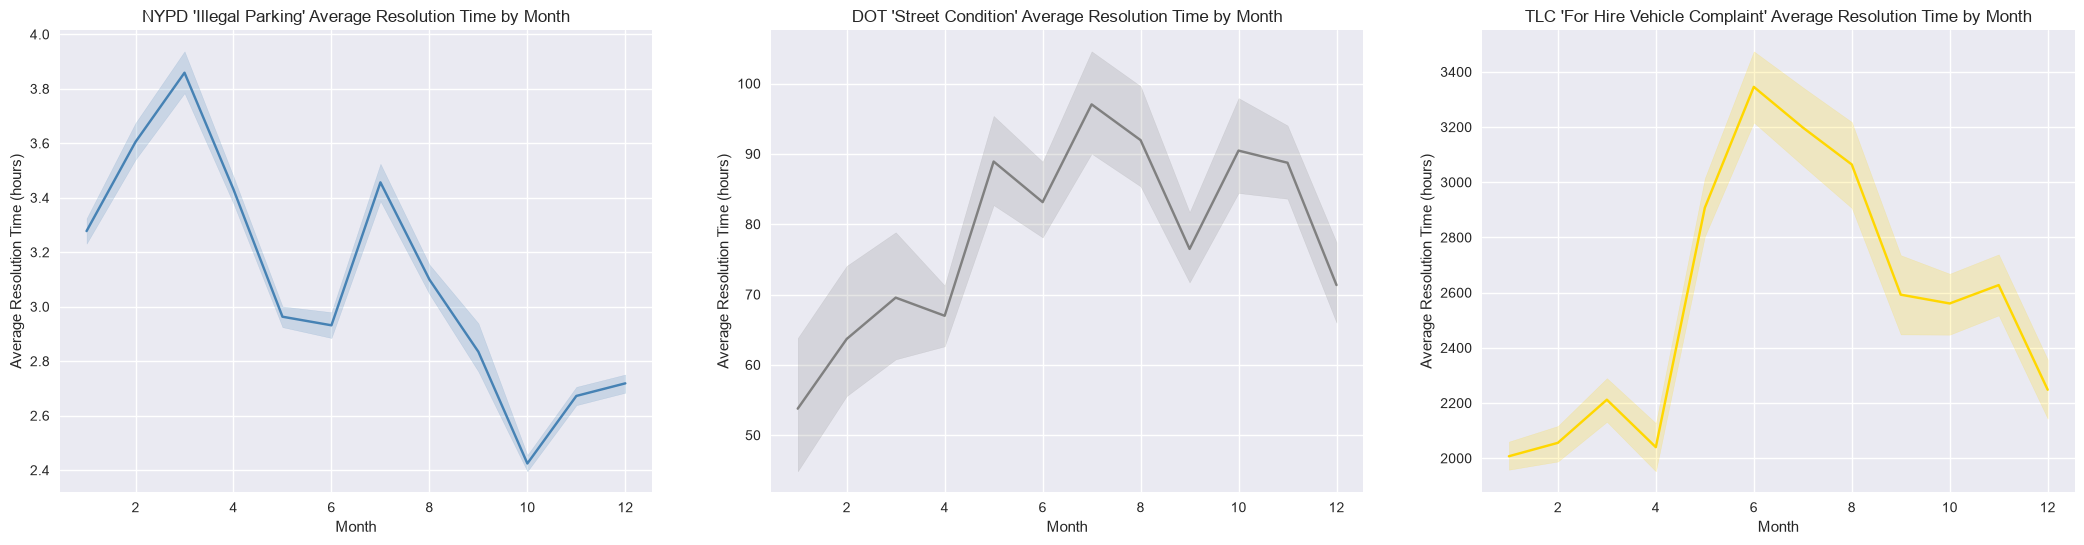

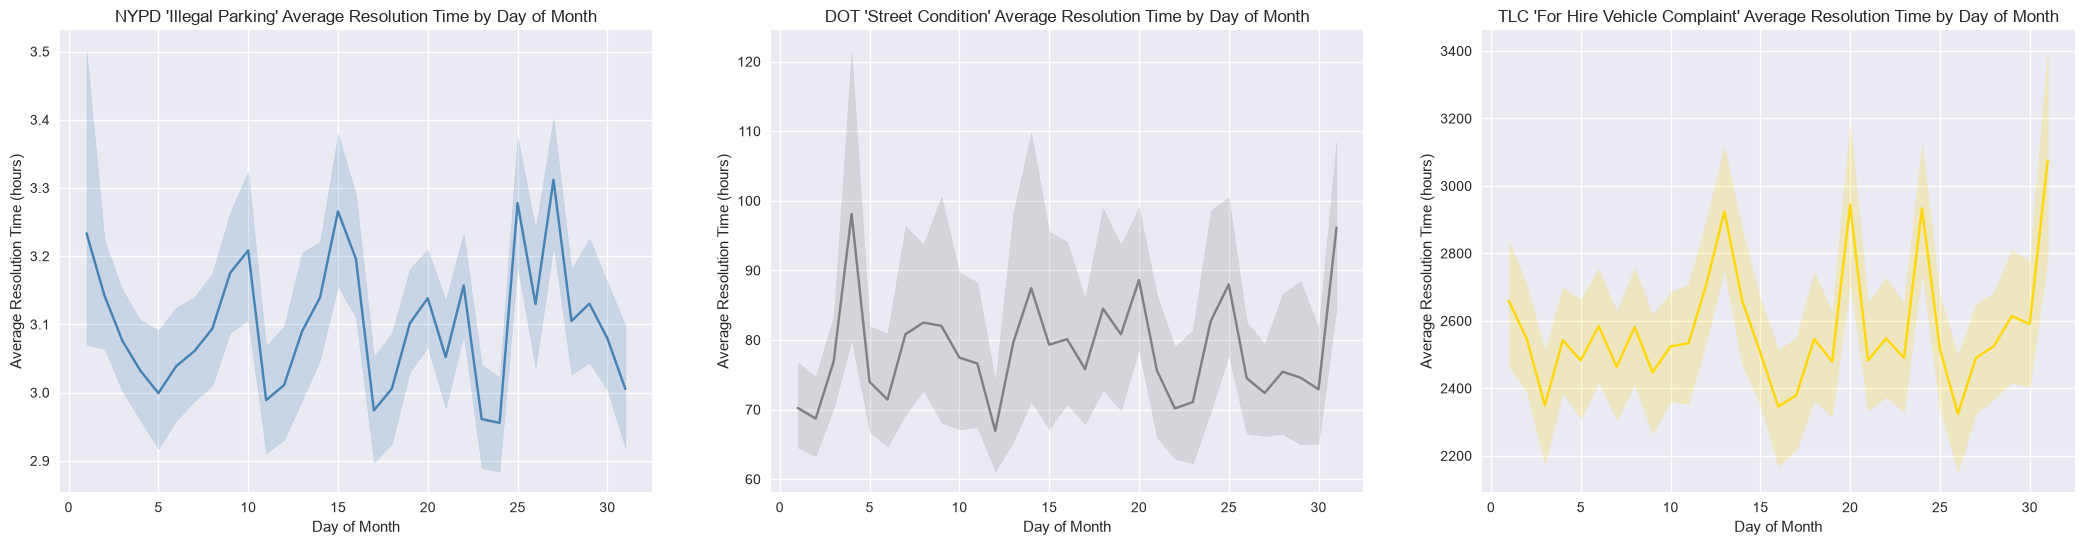

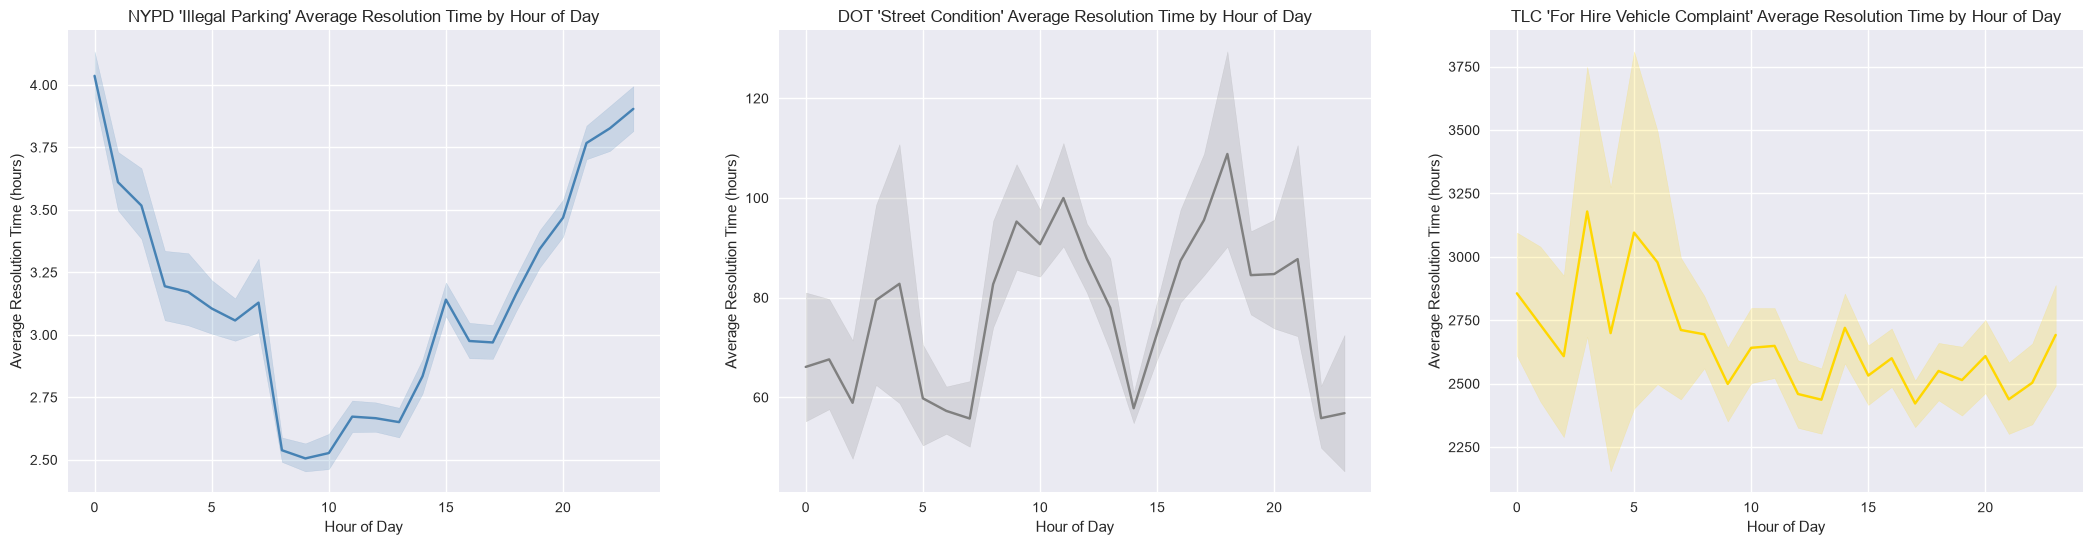

In [22]:
# by month
lineplots('Month', 'c_month')
# by day of month
lineplots('Day of Month', 'c_day')
# by hour
lineplots('Hour of Day', 'c_hour')

#### Time Analysis Observations
It is clear that consistently, the month and hour in which a problem is created does seem to 
correlate well with the average response time. Whereas the day of the month seems to give less
information with much more noise as well.

### Location Analysis
Location analysis can be found on the [**NYC311 Resolution Time Analysis**](https://public.tableau.com/app/profile/luis.jaco8183/viz/nyc311_17861374235790/nyc311).
Tableau is much more powerful as displaying location-based data with much higher levels of 
interactibility and detail. Please check out this viz if you are interested.

### Additional Analysis
Each problem has its own set of details which may or may not add information correlating to the 
`resolution_time` of a given problem, we will look at this in more detail below. We will also
analyze if `method` affects our target variable as well.

In [23]:
# setup
# give empty values the 'None' str -- there seems to not be any None data in the particular dataset
# used... however this remains useful with a dataset or problem which does contain None details.
nypd_p['detail'] = nypd_p['detail'].fillna('No Detail')
dot_p['detail'] = dot_p['detail'].fillna('No Detail')
tlc_p['detail'] = tlc_p['detail'].fillna('No Detail')

# group by statements for each agency & its top problem
nypd_p_detail = nypd_p.groupby('detail', dropna=False)['resolution_time'].mean().reset_index().sort_values('resolution_time', ascending=False)
dot_p_detail = dot_p.groupby('detail', dropna=False)['resolution_time'].mean().reset_index().sort_values('resolution_time', ascending=False)
tlc_p_detail = tlc_p.groupby('detail', dropna=False)['resolution_time'].mean().reset_index().sort_values('resolution_time', ascending=False)

# group by statements for method
nypd_p_method = nypd_p.groupby('method', dropna=False)['resolution_time'].mean().reset_index()
dot_p_method = dot_p.groupby('method', dropna=False)['resolution_time'].mean().reset_index()
tlc_p_method = tlc_p.groupby('method', dropna=False)['resolution_time'].mean().reset_index()

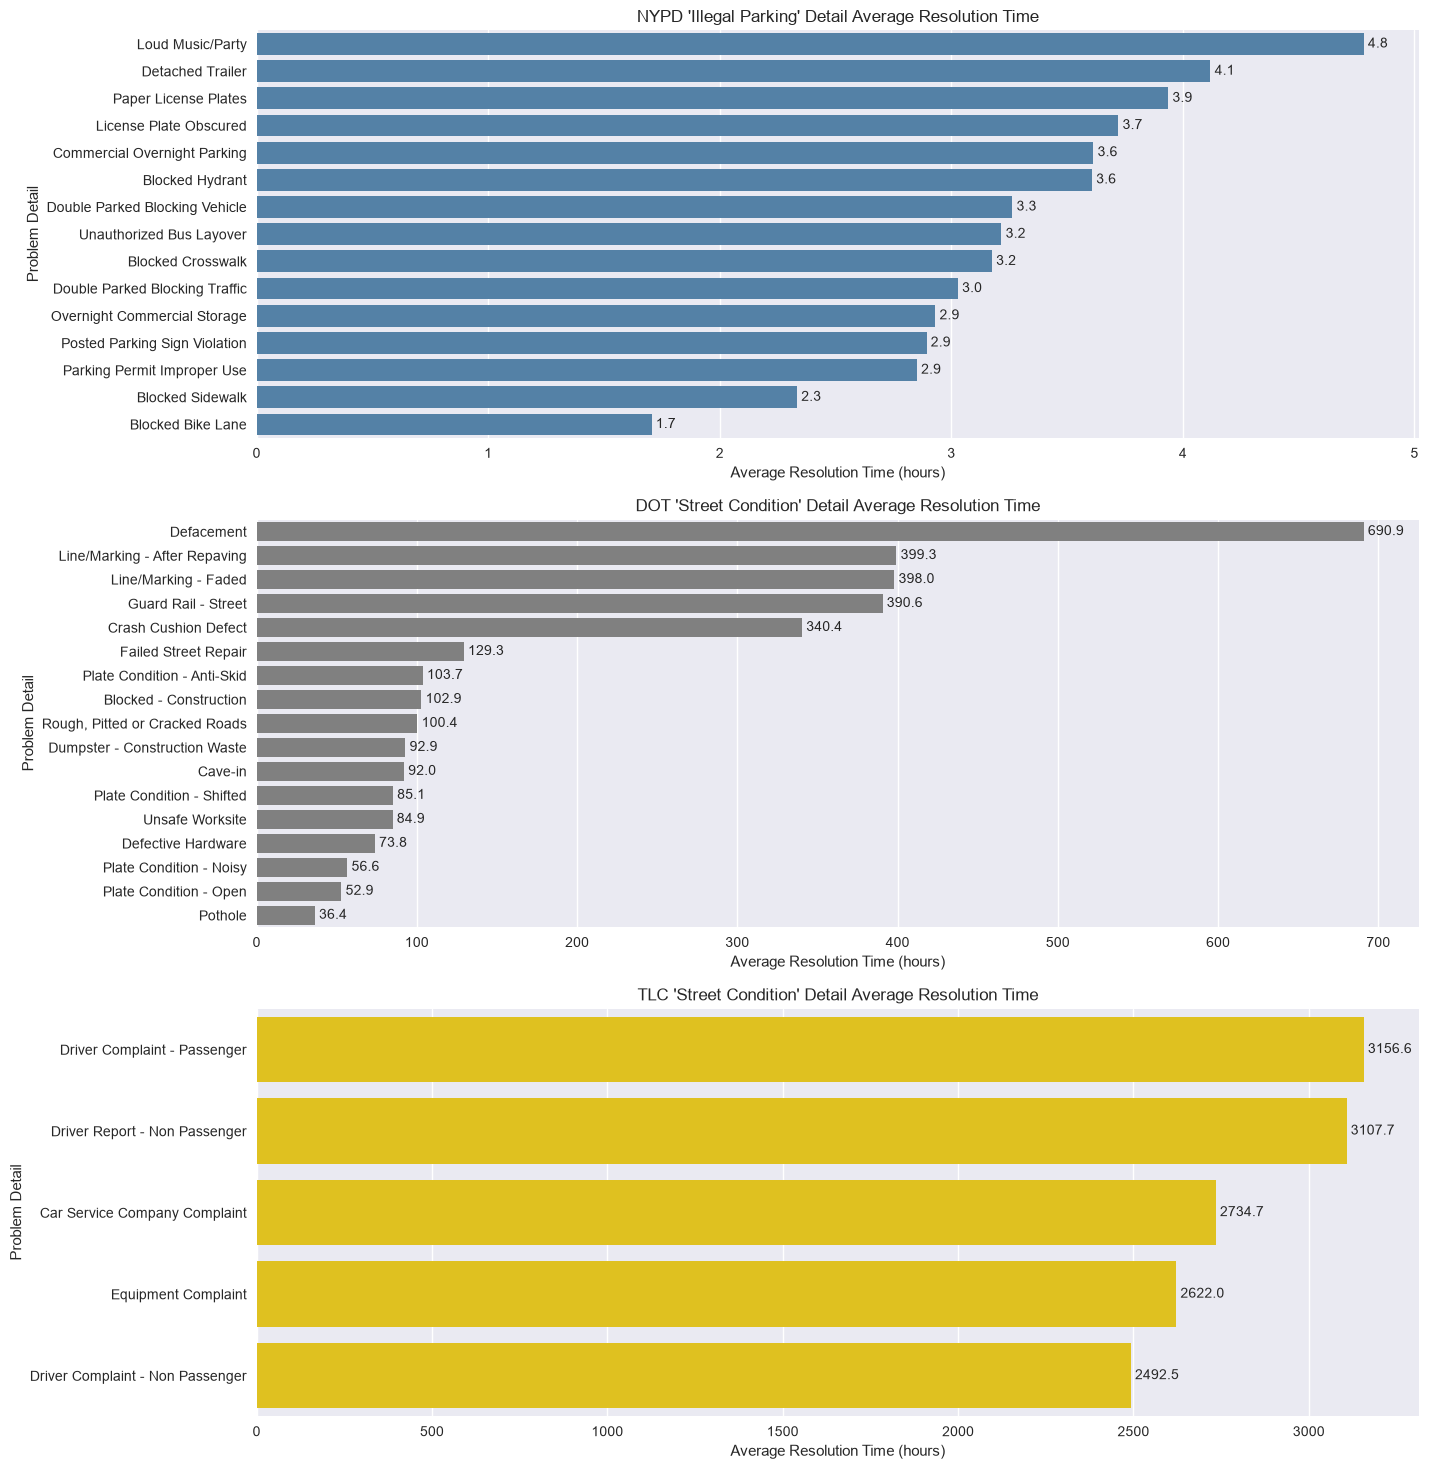

In [24]:
_, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 18))

# nypd
sns.barplot(nypd_p_detail, y='detail', x='resolution_time', ax=axes[0], color='steelblue')
axes[0].set(title='NYPD \'Illegal Parking\' Detail Average Resolution Time', xlabel='Average Resolution Time (hours)', ylabel='Problem Detail') 
axes[0].bar_label(axes[0].containers[0], fmt='%.1f', padding=3)

# tlc
sns.barplot(dot_p_detail, y='detail', x='resolution_time', ax=axes[1], color='gray')
axes[1].set(title='DOT \'Street Condition\' Detail Average Resolution Time', xlabel='Average Resolution Time (hours)', ylabel='Problem Detail') 
axes[1].bar_label(axes[1].containers[0], fmt='%.1f', padding=3)

# tlc
sns.barplot(tlc_p_detail, y='detail', x='resolution_time', ax=axes[2], color='gold')
axes[2].set(title='TLC \'Street Condition\' Detail Average Resolution Time', xlabel='Average Resolution Time (hours)', ylabel='Problem Detail') 
axes[2].bar_label(axes[2].containers[0], fmt='%.1f', padding=3)
plt.show()

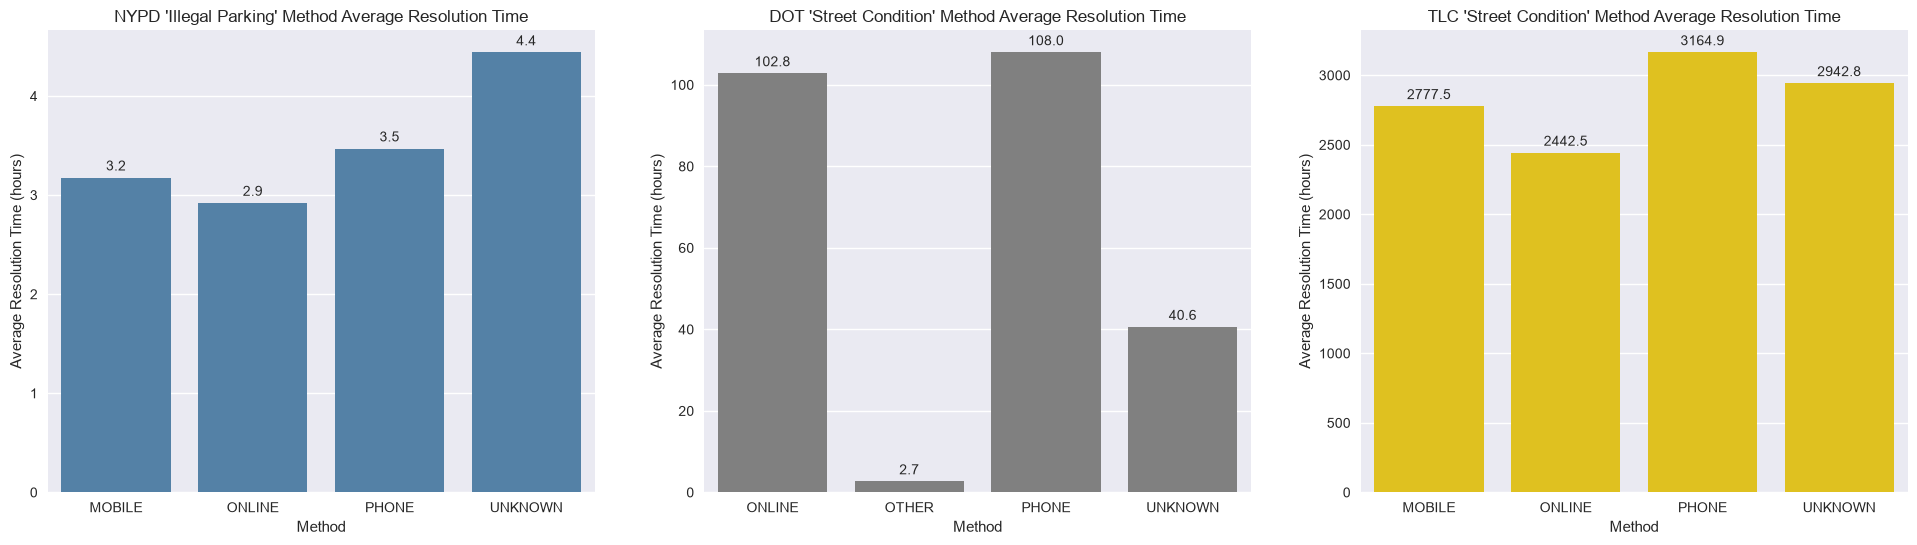

In [25]:
_, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 6))

# nypd
sns.barplot(nypd_p_method, x='method', y='resolution_time', ax=axes[0], color='steelblue')
axes[0].set(title='NYPD \'Illegal Parking\' Method Average Resolution Time', ylabel='Average Resolution Time (hours)', xlabel='Method') 
axes[0].bar_label(axes[0].containers[0], fmt='%.1f', padding=3)

# dot
sns.barplot(dot_p_method, x='method', y='resolution_time', ax=axes[1], color='gray')
axes[1].set(title='DOT \'Street Condition\' Method Average Resolution Time', ylabel='Average Resolution Time (hours)', xlabel='Method') 
axes[1].bar_label(axes[1].containers[0], fmt='%.1f', padding=3)

# tlc
sns.barplot(tlc_p_method, x='method', y='resolution_time', ax=axes[2], color='gold')
axes[2].set(title='TLC \'Street Condition\' Method Average Resolution Time', ylabel='Average Resolution Time (hours)', xlabel='Method') 
axes[2].bar_label(axes[2].containers[0], fmt='%.1f', padding=3)
plt.show()

Both `problem_detail` and `method` show clear signs of correlation with `resolution_time`. These
features seem to be associated with our target variable.

# Conclusions
After performing *Exploratory Data Analysis*, we can conclude that the features kept using 
[`/filter_data.ipynb`](/.filter_data.ipynb) show correlation to our target variable, `resolution_time`.

With this in mind, we can begin **preprocessing**, where we will define and create a pipeline which 
will properly format and process a dataset into a format which can be fed into our machine learning 
pipeline. After considering our datatypes and relationships between features and target variable, we
can perform the following transformations on the following features, dropping the rest:

| Feature | Null Response | Transformation | Notes |
|---|---|---|---|
| `problem` | — | One-hot encoding | |
| `detail`| Impute with "No Detail" | One-hot encoding | |
| `method`| Impute with "No Method" | One-hot encoding | |
| `borough` | — | One-hot encoding | |
| `zipcode` | — | Target encoding | |
| `c_month` | — | Cyclical encoding | Derived from `created` | 
| `c_day` | — | Cyclical encoding | Derived from `created` | 
| `c_hour`| — | Cyclical encoding | Derived from `created` | 

You can see the creation of the preprocessing pipeline in 
[`/preprocessing.ipynb`](./preprocessing.ipynb).